# `Pandas` 入门与实践

**学习目标：** 本节介绍 `Pandas` 数据结构、数据读取、筛选清洗、索引、合并和可视化，目标是完成常见表格数据分析任务。


## 基本概念


`Pandas` 是基于 `NumPy` 的开源 `Python` 数据分析库，常用于表格数据分析、数据清洗和数据准备。名称来源于 `Panel Data`，也就是面板数据。简单来说，可以把 `Pandas` 理解为 `Python` 生态中的表格数据处理工具。

虽然 `Pandas` 采用了大量 `NumPy` 编码风格，但二者关注点不同：`Pandas` 专门面向表格和混合类型数据，`NumPy` 更适合处理统一类型的数值数组。


## 安装


如果安装 `anaconda`，安装命令为：`conda install pandas`


如果没有安装 `anaconda`，安装命令为：`pip install pandas`


## `Pandas` 数据结构


使用 `Pandas` 前，需要先熟悉两个核心数据结构：`Series` 和 `DataFrame`。

`Series` 是一维带标签数组，底层可以基于 `NumPy` 数组。与普通 `NumPy` 数组不同，`Series` 可以为数据自定义标签，也就是索引 `index`，并通过索引访问数据。


下面导入常用库。在 `Python` 生态中，`NumPy` 惯例缩写为 `np`，`Pandas` 惯例缩写为 `pd`。


In [1]:
import numpy as np

rng = np.random.default_rng(42)
import pandas as pd
import matplotlib.pyplot as plt


### `Series`


`Series` 是一种类似于一维数组的对象，它由一组数据（各种 `NumPy` 数据类型）以及一组与之相关的数据标签（即索引）组成。

创建一个 `Series` 的基本语法如下：


`series = pd.Series(data, index)`


上面的 `data` 参数可以是任意数据对象，比如字典、列表甚至是 `NumPy` 数组，而 `index` 参数则是对 `data` 的索引值，类似字典的 `key`。


### 基于列表创建 `Series`


下面这个例子里，将创建一个 `Series` 对象，并用字符串对数字列表进行索引。


In [2]:
countries = ['USA', 'France', 'China']
my_data = [100, 200, 300]


In [3]:
pd.Series(data=my_data, index=countries)


USA       100
France    200
China     300
dtype: int64

注意：`index` 参数可以省略。如果不传入 `index`，`Pandas` 会使用默认整数索引，取值范围类似 `[0, ..., len(data) - 1]`。


In [4]:
pd.Series(data=my_data)


0    100
1    200
2    300
dtype: int64

### 基于 `NumPy` 创建 `Series`


In [5]:
array = np.array(my_data)


In [6]:
pd.Series(array)


0    100
1    200
2    300
dtype: int64

### 基于字典创建 `Series`

如果从 `Python` 字典创建 `Series`，`Pandas` 会把字典的键设置为 `Series` 的索引 `index`，并把对应的值作为数据 `data`。


In [7]:
my_dict = {'a': 50, 'b': 60, 'c' : 70, 'd' : 80}


In [8]:
pd.Series(my_dict)


a    50
b    60
c    70
d    80
dtype: int64

> 与 `NumPy` 数组不同，`Pandas` 的 `Series` 可以存放不同类型的对象。


从 `Series` 中获取数据，和从 `Python` 字典中获取数据基本一致：


In [9]:
countries = ['USA', 'France', 'China']
my_data = [100, 200, 300]
series = pd.Series(data=my_data, index=countries)
series['USA']


np.int64(100)

### `Series` 算术运算操作


对 `Series` 的算术运算都是基于 `index` 进行的。可以用加减乘除 `+`、`-`、`*`、`/` 等运算符对两个 `Series` 进行运算，`Pandas` 会根据索引 `index` 对齐数据，再计算对应位置的值。

如果 `Pandas` 在两个 `Series` 中找不到相同的 `index`，对应位置就返回缺失值 `NaN`。


In [10]:
series1 = pd.Series([1, 2, 3, 4], ['London', 'HongKong', 'Shanghai', 'Shenzhen'])
series2 = pd.Series([0, 6, 7, 8], ['London', 'Shenzhen', 'NewYork', 'Delhi'])


In [11]:
print(series1)
print()
print(series2)


London      1
HongKong    2
Shanghai    3
Shenzhen    4
dtype: int64

London      0
Shenzhen    6
NewYork     7
Delhi       8
dtype: int64


In [12]:
series1 - series2


Delhi       NaN
HongKong    NaN
London      1.0
NewYork     NaN
Shanghai    NaN
Shenzhen   -2.0
dtype: float64

In [13]:
series1 + series2


Delhi        NaN
HongKong     NaN
London       1.0
NewYork      NaN
Shanghai     NaN
Shenzhen    10.0
dtype: float64

In [14]:
series1 * series2


Delhi        NaN
HongKong     NaN
London       0.0
NewYork      NaN
Shanghai     NaN
Shenzhen    24.0
dtype: float64

In [15]:
series1 / series2


Delhi            NaN
HongKong         NaN
London           inf
NewYork          NaN
Shanghai         NaN
Shenzhen    0.666667
dtype: float64

### `DataFrame`


### 创建 `DataFrame`


`DataFrame` 是二维表格数据结构，数据按行和列组织。通过 `DataFrame`，可以方便地完成列选择、行筛选、索引修改、数据重组和多条件筛选等操作。

构建 `DataFrame` 对象的基本语法如下：

```python
df = pd.DataFrame(data, index=index, columns=columns)
```


创建一个 5 行 4 列的 `DataFrame`，并填上随机数据：


In [16]:
dataframe = pd.DataFrame(data=rng.integers(low=1, high=10, size=(5, 4)))
print(dataframe)


   0  1  2  3
0  1  7  6  4
1  4  8  1  7
2  2  1  5  9
3  7  7  7  8
4  5  2  8  5


下面的例子使用字典创建 `DataFrame`。需要注意，索引数量必须与字典中每个 `value` 的长度一致。


In [17]:
data = {'col one': [100, 200, 300],
     'col two': [400, 500, 600],
     'col three':[700, 800, 900]}
df = pd.DataFrame(data, index=['a', 'b', 'c'])
display(df)


,col one,col two,col three
a,100,400,700
b,200,500,800
c,300,600,900


### 更改列名称


更改列名最灵活的方式是使用 `rename()` 函数。可以传递一个字典，其中 `keys` 为原列名，`values` 为新列名，还可以指定 `axis`


In [18]:
df = df.rename({'col one':'col_one',
                'col two':'col_two'},
                axis='columns')
df


,col_one,col_two,col three
a,100,400,700
b,200,500,800
c,300,600,900


如果需要一次性重命名所有列，更简单的方式是直接重写 `DataFrame` 的 `columns` 属性：


In [19]:
df.columns = ['col_one', 'col_two', 'col_three']
df


,col_one,col_two,col_three
a,100,400,700
b,200,500,800
c,300,600,900


如果你需要做的仅仅是将空格换成下划线，那么更好的办法是用 `str.replace()` 方法。


In [20]:
data = {'col one': [100, 200, 300],
     'col two': [400, 500, 600],
     'col three':[700, 800, 900]}
df = pd.DataFrame(data, index=list('abc'))
df


,col one,col two,col three
a,100,400,700
b,200,500,800
c,300,600,900


In [21]:
df.columns = df.columns.str.replace(' ', '_')
df


,col_one,col_two,col_three
a,100,400,700
b,200,500,800
c,300,600,900


如果要在列名中添加前缀或者后缀，可以使用 `add_prefix()` 和 `add_suffix()` 函数。


In [22]:
df.add_prefix('X_')


,X_col_one,X_col_two,X_col_three
a,100,400,700
b,200,500,800
c,300,600,900


In [23]:
df.add_suffix('_Y')


,col_one_Y,col_two_Y,col_three_Y
a,100,400,700
b,200,500,800
c,300,600,900


> 需要注意，上面两个函数默认不会修改原来的 `DataFrame`，而是返回修改后的新对象。


In [24]:
df


,col_one,col_two,col_three
a,100,400,700
b,200,500,800
c,300,600,900


In [25]:
dfx = df.add_prefix('X_')
dfx


,X_col_one,X_col_two,X_col_three
a,100,400,700
b,200,500,800
c,300,600,900


### 获取 `DataFrame` 中的列


要获取一列的数据，还是用中括号 `[ ]` 的方式，跟 `Series` 类似，或者用 `.column_name` 的方式。


In [26]:
df['col_one']


a    100
b    200
c    300
Name: col_one, dtype: int64

In [27]:
df.col_one


a    100
b    200
c    300
Name: col_one, dtype: int64

如果要获取多列，可以传入由列名组成的列表，返回结果是一个 `DataFrame`。


In [28]:
df[['col_one', 'col_two']]


,col_one,col_two
a,100,400
b,200,500
c,300,600


### 向 `DataFrame` 里增加数据列


增加数据列有两种办法：可以从头开始定义一个 `pd.Series`，再把它放到表中，也可以利用现有的列来产生需要的新列。


In [29]:
df['col_four'] = pd.Series([1000, 1100, 1200]).values
df


,col_one,col_two,col_three,col_four
a,100,400,700,1000
b,200,500,800,1100
c,300,600,900,1200


从现有的列创建新列：


In [30]:
df['col_one_plus_two'] = df['col_one'] + df['col_two']
df


,col_one,col_two,col_three,col_four,col_one_plus_two
a,100,400,700,1000,500
b,200,500,800,1100,700
c,300,600,900,1200,900


### 从 `DataFrame` 中删除行或列


想要删除某一行或一列，可以用 `.drop()` 函数。在使用这个函数的时候，你需要先指定具体的删除方向，`axis=0 ` 对应的是行，而 `axis=1` 对应的是列 column 。

删除列：


In [31]:
df.drop('col_one_plus_two', axis=1)


,col_one,col_two,col_three,col_four
a,100,400,700,1000
b,200,500,800,1100
c,300,600,900,1200


删除行：


In [32]:
df.drop('a', axis=0)


,col_one,col_two,col_three,col_four,col_one_plus_two
b,200,500,800,1100,700
c,300,600,900,1200,900


> `.drop()` 默认不会原地删除行或列，而是返回一个新 `DataFrame`。实际项目中更推荐把返回值赋给变量，避免隐式修改带来的副作用，也更利于链式处理和测试。


In [33]:
df


,col_one,col_two,col_three,col_four,col_one_plus_two
a,100,400,700,1000,500
b,200,500,800,1100,700
c,300,600,900,1200,900


如果要更新当前变量，直接把返回值赋回去即可。


In [34]:
df = df.drop("a", axis=0)
df


,col_one,col_two,col_three,col_four,col_one_plus_two
b,200,500,800,1100,700
c,300,600,900,1200,900


### 获取 `DataFrame` 中的一行或多行数据


要获取某一行，你需要用 `.loc[]` 来按索引（标签名）引用这一行，或者用 `.iloc[]`，按这行在表中的位置（行数）来引用。


In [35]:
df.loc['b']


col_one              200
col_two              500
col_three            800
col_four            1100
col_one_plus_two     700
Name: b, dtype: int64

In [36]:
df.loc[['b', 'c']]


,col_one,col_two,col_three,col_four,col_one_plus_two
b,200,500,800,1100,700
c,300,600,900,1200,900


In [37]:
df.iloc[0]


col_one              200
col_two              500
col_three            800
col_four            1100
col_one_plus_two     700
Name: b, dtype: int64

In [38]:
df.iloc[[0, 1]]


,col_one,col_two,col_three,col_four,col_one_plus_two
b,200,500,800,1100,700
c,300,600,900,1200,900


可以用 `.loc[]` 来指定具体的行列范围，并生成一个子数据表。


In [39]:
df.loc['b', 'col_one']


np.int64(200)

In [40]:
df.loc[['b', 'c'], ['col_one', 'col_two']]


,col_one,col_two
b,200,500
c,300,600


### 条件筛选


用中括号 `[ ]` 的方式，除了直接指定选中某些列外，还能接收一个条件语句，` 然后筛选出符合条件的行/列 `。


In [41]:
df = pd.DataFrame(data=rng.standard_normal((5, 4)),
                  index=['a', 'b', 'c', 'd', 'e'],
                  columns=['W', 'X', 'Y', 'Z'])
df


,W,X,Y,Z
a,0.879398,0.777792,0.066031,1.127241
b,0.467509,-0.859292,0.368751,-0.958883
c,0.878450,-0.049926,-0.184862,-0.680930
d,1.222541,-0.154529,-0.428328,-0.352134
e,0.532309,0.365444,0.412733,0.430821


In [42]:
df[df['X'] > 0.5]


,W,X,Y,Z
a,0.879398,0.777792,0.066031,1.127241


In [43]:
df[df.X > 0.5]


,W,X,Y,Z
a,0.879398,0.777792,0.066031,1.127241


只看 `W` 列中，`X > 0.5` 的数据：


In [44]:
df[df['X'] > 0.5]['W']


a    0.879398
Name: W, dtype: float64

In [45]:
df[df['X']>0.5][['X','Y']]


,X,Y
a,0.777792,0.066031


可以用逻辑运算符 `&` 和 `|` 连接多个条件表达式，并一次性应用到当前 `DataFrame` 上。


In [46]:
df[~((df['W'] > 0) | (df['X'] > 0.5))]


,W,X,Y,Z


In [47]:
df[(df['W'] < 0) & (df['X'] < 0.5)]


,W,X,Y,Z


### 重置 `DataFrame` 的索引


可以用 `.reset_index()` 简单地把整个表的索引都重置掉。这个方法将把目标 `DataFrame` 的索引保存在一个叫 `index` 的列中，而把表格的索引变成默认的从零开始的数字，也就是 `[0, ..., len(data) - 1]` 。


In [48]:
df.reset_index()


,index,W,X,Y,Z
0,a,0.879398,0.777792,0.066031,1.127241
1,b,0.467509,-0.859292,0.368751,-0.958883
2,c,0.878450,-0.049926,-0.184862,-0.680930
3,d,1.222541,-0.154529,-0.428328,-0.352134
4,e,0.532309,0.365444,0.412733,0.430821


加上 `drop=True` 参数丢弃原来的索引。


In [49]:
df.reset_index(drop=True)


,W,X,Y,Z
0,0.879398,0.777792,0.066031,1.127241
1,0.467509,-0.859292,0.368751,-0.958883
2,0.878450,-0.049926,-0.184862,-0.680930
3,1.222541,-0.154529,-0.428328,-0.352134
4,0.532309,0.365444,0.412733,0.430821


和删除操作类似，`.reset_index()` 会返回一个新 `DataFrame`。推荐用赋值表达意图。


In [50]:
df


,W,X,Y,Z
a,0.879398,0.777792,0.066031,1.127241
b,0.467509,-0.859292,0.368751,-0.958883
c,0.878450,-0.049926,-0.184862,-0.680930
d,1.222541,-0.154529,-0.428328,-0.352134
e,0.532309,0.365444,0.412733,0.430821


In [51]:
df = df.reset_index(drop=True)
df


,W,X,Y,Z
0,0.879398,0.777792,0.066031,1.127241
1,0.467509,-0.859292,0.368751,-0.958883
2,0.878450,-0.049926,-0.184862,-0.680930
3,1.222541,-0.154529,-0.428328,-0.352134
4,0.532309,0.365444,0.412733,0.430821


### 设置 `DataFrame` 的索引值


还可以用 `.set_index()` 方法，将 `DataFrame` 里的某一列作为索引来用。


In [52]:
df['index'] = ['a', 'b', 'c', 'd', 'e']
df


,W,X,Y,Z,index
0,0.879398,0.777792,0.066031,1.127241,a
1,0.467509,-0.859292,0.368751,-0.958883,b
2,0.878450,-0.049926,-0.184862,-0.680930,c
3,1.222541,-0.154529,-0.428328,-0.352134,d
4,0.532309,0.365444,0.412733,0.430821,e


In [53]:
df.set_index('index')


,W,X,Y,Z
index,,,,
a,0.879398,0.777792,0.066031,1.127241
b,0.467509,-0.859292,0.368751,-0.958883
c,0.878450,-0.049926,-0.184862,-0.680930
d,1.222541,-0.154529,-0.428328,-0.352134
e,0.532309,0.365444,0.412733,0.430821


同样地，`.set_index()` 推荐把返回值赋给变量，而不是依赖 `inplace=True`。


In [54]:
df


,W,X,Y,Z,index
0,0.879398,0.777792,0.066031,1.127241,a
1,0.467509,-0.859292,0.368751,-0.958883,b
2,0.878450,-0.049926,-0.184862,-0.680930,c
3,1.222541,-0.154529,-0.428328,-0.352134,d
4,0.532309,0.365444,0.412733,0.430821,e


In [55]:
df = df.set_index("index")
df


,W,X,Y,Z
index,,,,
a,0.879398,0.777792,0.066031,1.127241
b,0.467509,-0.859292,0.368751,-0.958883
c,0.878450,-0.049926,-0.184862,-0.680930
d,1.222541,-0.154529,-0.428328,-0.352134
e,0.532309,0.365444,0.412733,0.430821


In [56]:
df.index.name = "mxh"
df


,W,X,Y,Z
mxh,,,,
a,0.879398,0.777792,0.066031,1.127241
b,0.467509,-0.859292,0.368751,-0.958883
c,0.878450,-0.049926,-0.184862,-0.680930
d,1.222541,-0.154529,-0.428328,-0.352134
e,0.532309,0.365444,0.412733,0.430821


### 多级索引与命名索引


多级索引是由元组组成的索引结构。可以通过 `pd.MultiIndex.from_arrays()` 从多个数组创建，也可以通过 `pd.MultiIndex.from_tuples()` 从元组列表创建，或通过 `pd.MultiIndex.from_product()` 从多个可迭代对象的笛卡尔积创建。


In [57]:
outside = ['level 0', 'level 0', 'level 0', 'level 1', 'level 1', 'level 1']
inside = [21, 22, 23, 21, 22, 23]
myindex = list(zip(outside, inside))


In [58]:
myindex


[('level 0', 21),
 ('level 0', 22),
 ('level 0', 23),
 ('level 1', 21),
 ('level 1', 22),
 ('level 1', 23)]

接下来，调用 `pd.MultiIndex.from_tuples(my_index)` 生成一个多级索引对象：


In [59]:
myindex = pd.MultiIndex.from_tuples(myindex)
myindex


MultiIndex([('level 0', 21),
            ('level 0', 22),
            ('level 0', 23),
            ('level 1', 21),
            ('level 1', 22),
            ('level 1', 23)],
           )

最后，将这个多级索引对象转成一个 `DataFrame`：


In [60]:
df = pd.DataFrame(rng.standard_normal((6, 2)), index=myindex, columns=['A', 'B'])
df


A         B
level 0 21  2.141648 -0.406415
        22 -0.512243 -0.813773
        23  0.615979  1.128972
level 1 21 -0.113947 -0.840156
        22 -0.824481  0.650593
        23  0.743254  0.543154

要获取多级索引中的数据，还是用到 `.loc[]` 。比如，先获取 `'level 0'` 下的数据：


In [61]:
df.loc['level 0']


,A,B
21,2.141648,-0.406415
22,-0.512243,-0.813773
23,0.615979,1.128972


然后再用一次 .loc[]，获取下一层 21 里的数据：


In [62]:
df.loc['level 0'].loc[21]


A    2.141648
B   -0.406415
Name: 21, dtype: float64

如上所示，`DataFrame` 的头两个索引列没有名字，看起来不太易懂。可以用 `.index.names` 给它们加上名字：


In [63]:
df.index.names = ['level', 'num']


In [64]:
df


A         B
level   num                    
level 0 21   2.141648 -0.406415
        22  -0.512243 -0.813773
        23   0.615979  1.128972
level 1 21  -0.113947 -0.840156
        22  -0.824481  0.650593
        23   0.743254  0.543154

交叉选择行和列中的数据


可以用 `.xs()` 方法轻松获取到多级索引中某些特定级别的数据。比如，需要找到所有 `Levels` 中，`Num = 22` 的行：


In [65]:
df.xs(22, level='num')


,A,B
level,,
level 0,-0.512243,-0.813773
level 1,-0.824481,0.650593


### 数据堆叠


堆叠基本上就是简单地把多个 `DataFrame` 堆在一起，拼成一个更大的 `DataFrame`。当你进行堆叠的时候，请务必注意你数据表的索引和列的延伸方向，堆叠的方向要和它一致。

比如，有这样 3 个 `DataFrame`：


In [66]:
df1 = pd.DataFrame(data=[['A0', 'B0', 'C0', 'D0'],
                         ['A1', 'B1', 'C1', 'D1'],
                         ['A2', 'B2', 'C2', 'D2'],
                         ['A3', 'B3', 'C3', 'D3'],
                         ['A31', 'B31', 'C31', 'D31']],
                   columns=['A', 'B', 'C', 'D'])
df1


,A,B,C,D
0,A0,B0,C0,D0
1,A1,B1,C1,D1
2,A2,B2,C2,D2
3,A3,B3,C3,D3
4,A31,B31,C31,D31


In [67]:
df2 = pd.DataFrame(data=[['A4', 'B4', 'C4', 'D4'],
                         ['A5', 'B5', 'C5', 'D5'],
                         ['A6', 'B6', 'C6', 'D6'],
                         ['A7', 'B7', 'C7', 'D7']],
                   columns=['A', 'B', 'C', 'D'])
df2


,A,B,C,D
0,A4,B4,C4,D4
1,A5,B5,C5,D5
2,A6,B6,C6,D6
3,A7,B7,C7,D7


In [68]:
df3 = pd.DataFrame(data=[['A8', 'B8', 'C8', 'D8'],
                         ['A9', 'B9', 'C9', 'D9'],
                         ['A10', 'B10', 'C10', 'D10'],
                         ['A11', 'B11', 'C11', 'D11']],
                   columns=['A', 'B', 'C', 'D'])
df3


,A,B,C,D
0,A8,B8,C8,D8
1,A9,B9,C9,D9
2,A10,B10,C10,D10
3,A11,B11,C11,D11


In [69]:
dffull = pd.concat([df1, df2, df3])
dffull


,A,B,C,D
0,A0,B0,C0,D0
1,A1,B1,C1,D1
2,A2,B2,C2,D2
3,A3,B3,C3,D3
4,A31,B31,C31,D31
0,A4,B4,C4,D4
1,A5,B5,C5,D5
2,A6,B6,C6,D6
3,A7,B7,C7,D7
0,A8,B8,C8,D8


In [70]:
dffull.loc[0]


,A,B,C,D
0,A0,B0,C0,D0
0,A4,B4,C4,D4
0,A8,B8,C8,D8


重置索引


In [71]:
dffull = dffull.reset_index(drop=True)
dffull


,A,B,C,D
0,A0,B0,C0,D0
1,A1,B1,C1,D1
2,A2,B2,C2,D2
3,A3,B3,C3,D3
4,A31,B31,C31,D31
5,A4,B4,C4,D4
6,A5,B5,C5,D5
7,A6,B6,C6,D6
8,A7,B7,C7,D7
9,A8,B8,C8,D8


In [72]:
dffull


,A,B,C,D
0,A0,B0,C0,D0
1,A1,B1,C1,D1
2,A2,B2,C2,D2
3,A3,B3,C3,D3
4,A31,B31,C31,D31
5,A4,B4,C4,D4
6,A5,B5,C5,D5
7,A6,B6,C6,D6
8,A7,B7,C7,D7
9,A8,B8,C8,D8


没有指定堆叠方向时，`Pandas` 默认按行堆叠，把每个表的索引按顺序叠加。

如果要按列方向堆叠，需要传入 `axis=1` 参数：


In [73]:
pd.concat([df1, df2, df3], axis=1)


,A,B,C,D,A,B,C,D,A,B,C,D
0,A0,B0,C0,D0,A4,B4,C4,D4,A8,B8,C8,D8
1,A1,B1,C1,D1,A5,B5,C5,D5,A9,B9,C9,D9
2,A2,B2,C2,D2,A6,B6,C6,D6,A10,B10,C10,D10
3,A3,B3,C3,D3,A7,B7,C7,D7,A11,B11,C11,D11
4,A31,B31,C31,D31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


注意，这里出现了一大堆空值。因为用来堆叠的 3 个 `DataFrame` 里，有许多索引是没有对应数据的。因此，当你使用 `pd.concat()` 的时候，一定要注意堆叠方向的坐标轴（行或列）含有所需的所有数据。


### 数据归并


使用 `pd.merge()` 可以按键合并多个 `DataFrame`，其行为类似 SQL 表连接。

基本语法：

```python
pd.merge(left, right, how="inner", on="Key")
```

参数说明：

- `left`：左侧 `DataFrame`。
- `right`：右侧 `DataFrame`。
- `how`：合并方式。常见值包括 `"inner"`、`"outer"`、`"left"` 和 `"right"`。
- `on`：用于合并的键列。左右两个 `DataFrame` 中都需要包含该列。


In [74]:
left = pd.DataFrame({'key': ['K0', 'K1', 'K2', 'K3', 'K4'],
                    'A': ['A0', 'A1', 'A2', 'A3', 'A4'],
                    'B': ['B0', 'B1', 'B2', 'B3', 'B4']})
right = pd.DataFrame({'key': ['K0', 'K1', 'K2', 'K3'],
                    'C': ['C0', 'C1', 'C2', 'C3'],
                    'D': ['D0', 'D1', 'D2', 'D3']})


In [75]:
left


,key,A,B
0,K0,A0,B0
1,K1,A1,B1
2,K2,A2,B2
3,K3,A3,B3
4,K4,A4,B4


In [76]:
right


,key,C,D
0,K0,C0,D0
1,K1,C1,D1
2,K2,C2,D2
3,K3,C3,D3


In [77]:
pd.merge(left, right, how='inner', on='key')


,key,A,B,C,D
0,K0,A0,B0,C0,D0
1,K1,A1,B1,C1,D1
2,K2,A2,B2,C2,D2
3,K3,A3,B3,C3,D3


In [78]:
pd.merge(left, right, how='outer', on='key')


,key,A,B,C,D
0,K0,A0,B0,C0,D0
1,K1,A1,B1,C1,D1
2,K2,A2,B2,C2,D2
3,K3,A3,B3,C3,D3
4,K4,A4,B4,NaN,NaN


也可以传入多个 `on` 参数，这样就能按多个键值进行归并：


In [79]:
left = pd.DataFrame({'key1': ['K0', 'K0', 'K1', 'K2', 'K3'],
                     'key2': ['K0', 'K1', 'K2', 'K3', 'K4'],
                     'A': ['A0', 'A1', 'A2', 'A3', 'A4'],
                     'B': ['B0', 'B1', 'B2', 'B3', 'B4']})
right = pd.DataFrame({'key1': ['K0', 'K1', 'K1', 'K2'],
                      'key2': ['K0', 'K0', 'K0', 'K0'],
                      'C': ['C0', 'C1', 'C2', 'C3'],
                      'D': ['D0', 'D1', 'D2', 'D3']})


In [80]:
left


,key1,key2,A,B
0,K0,K0,A0,B0
1,K0,K1,A1,B1
2,K1,K2,A2,B2
3,K2,K3,A3,B3
4,K3,K4,A4,B4


In [81]:
right


,key1,key2,C,D
0,K0,K0,C0,D0
1,K1,K0,C1,D1
2,K1,K0,C2,D2
3,K2,K0,C3,D3


In [82]:
pd.merge(left, right, on=['key1', 'key2'])
# 默认内连接
# key1、key2 同时匹配


,key1,key2,A,B,C,D
0,K0,K0,A0,B0,C0,D0


In [83]:
pd.merge(left, right, on=['key1', 'key2'], how='outer')
# 默认内连接
# 外连接保留两侧键


,key1,key2,A,B,C,D
0,K0,K0,A0,B0,C0,D0
1,K0,K1,A1,B1,NaN,NaN
2,K1,K0,NaN,NaN,C1,D1
3,K1,K0,NaN,NaN,C2,D2
4,K1,K2,A2,B2,NaN,NaN
5,K2,K0,NaN,NaN,C3,D3
6,K2,K3,A3,B3,NaN,NaN
7,K3,K4,A4,B4,NaN,NaN


### 索引连接


如果要把两个表连在一起，然而它们之间没有太多共同的列，那么你可以试试 `.join()` 方法。和 `.merge()` 不同，连接采用索引作为公共的键，而不是某一列。


In [84]:
import pandas as pd
left = pd.DataFrame({'A': ['A0', 'A1', 'A2', 'A3', 'A4'],
                    'B': ['B0', 'B1', 'B2', 'B3', 'B4']}, index=['2000', '2001', '2006', '2003', '2004'])
right = pd.DataFrame({'C': ['C0', 'C1', 'C2', 'C3'],
                    'D': ['D0', 'D1', 'D2', 'D3']}, index=['2000', '2007', '2003', '2004'])


In [85]:
left


,A,B
2000,A0,B0
2001,A1,B1
2006,A2,B2
2003,A3,B3
2004,A4,B4


In [86]:
right


,C,D
2000,C0,D0
2007,C1,D1
2003,C2,D2
2004,C3,D3


In [87]:
left.join(right)


,A,B,C,D
2000,A0,B0,C0,D0
2001,A1,B1,NaN,NaN
2006,A2,B2,NaN,NaN
2003,A3,B3,C2,D2
2004,A4,B4,C3,D3


同样，`inner` 代表交集，`outer` 代表并集。


In [88]:
left.join(right, how='inner')


,A,B,C,D
2000,A0,B0,C0,D0
2003,A3,B3,C2,D2
2004,A4,B4,C3,D3


## 数据处理


### 读取 `CSV` 文件


使用 `pd.read_csv()` 可以将 `CSV` 文件读取为 `DataFrame` 对象：


In [89]:
df = pd.read_csv("../../resources/datasets/titanic.csv")
df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


读取本地 `CSV` 文件时，如果文件包含中文字符，通常需要根据文件实际编码设置 `encoding` 参数。当前项目只保留了可运行的 `titanic.csv` 示例。


In [90]:
df = pd.read_csv("../../resources/datasets/titanic.csv", encoding="utf-8")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [91]:
df = pd.read_csv("../../resources/datasets/titanic.csv")


读取完数据后，可以通过以下属性和方法快速了解数据。

**属性**

- `df.columns`：数据集中的所有列名。

**方法**

- `df.head()`：预览数据集前 5 行。
- `df.tail()`：预览数据集后 5 行。
- `df.info()`：显示每列名称、非空值数量、数据类型和内存占用等信息。
- `df.describe()`：展示数值类型字段的描述性统计信息，并默认过滤缺失值。
- `df.describe(include="all")`：统计所有类型的数据。
- `df.describe(include=[np.number])`：只统计数值类型字段。
- `df.describe(include=[object])`：只统计 `object` 类型字段。
- `df.describe(include="O")`：只统计字符串类型字段。
- `df.describe(percentiles=[0.25, 0.5, 0.75])`：设置输出的百分位数。


In [92]:
df.head() # 默认显示最前5条数据


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [93]:
df.tail() # 默认显示最后5条数据


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [94]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [95]:
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 根据类型选取数据


显示数据类型


In [96]:
df.dtypes


PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

通过数据类型选择列


In [97]:
df.select_dtypes(include='number').head()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


选取数据类型为 `object` 的列


In [98]:
df.select_dtypes(include='object').head()


/tmp/ipykernel_17985/1150064832.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').head()


,Name,Sex,Ticket,Cabin,Embarked
0,"Braund, Mr. Owen Harris",male,A/5 21171,NaN,S
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,PC 17599,C85,C
2,"Heikkinen, Miss. Laina",female,STON/O2. 3101282,NaN,S
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,113803,C123,S
4,"Allen, Mr. William Henry",male,373450,NaN,S


选取多种数据类型，只需要传递一个列表即可


In [99]:
df.select_dtypes(include=['number', 'object', 'category', 'datetime']).head()


/tmp/ipykernel_17985/1191183739.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include=['number', 'object', 'category', 'datetime']).head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


可以排除特定类型的列


In [100]:
df.select_dtypes(exclude='number').head()


,Name,Sex,Ticket,Cabin,Embarked
0,"Braund, Mr. Owen Harris",male,A/5 21171,NaN,S
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,PC 17599,C85,C
2,"Heikkinen, Miss. Laina",female,STON/O2. 3101282,NaN,S
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,113803,C123,S
4,"Allen, Mr. William Henry",male,373450,NaN,S


### 类型转换


In [101]:
import pandas as pd
df = pd.DataFrame({'col_one':['1.1', '2.2', '3.3'],
                   'col_two':['4.4', '5.5', '6.6'],
                   'col_three':['7.7', '8.8', '-']})
display(df)
df.info()


,col_one,col_two,col_three
0,1.1,4.4,7.7
1,2.2,5.5,8.8
2,3.3,6.6,-


<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   col_one    3 non-null      str  
 1   col_two    3 non-null      str  
 2   col_three  3 non-null      str  
dtypes: str(3)
memory usage: 229.0 bytes


通过 `astype` 方法转换


In [102]:
df['col_one'].astype('float')


0    1.1
1    2.2
2    3.3
Name: col_one, dtype: float64

也可以多个转换


In [103]:
df.astype({'col_one':'float', 'col_two':'float'}).dtypes


col_one      float64
col_two      float64
col_three        str
dtype: object

`astype()` 用于类型转换，但要求数据本身可以被转换；如果数据中存在无效值，转换可能报错。此时可以使用 `pd.to_numeric()`，并通过 `errors="coerce"` 将无效数据转换为 `NaN`。

函数签名：

```python
pandas.to_numeric(arg, errors="raise", downcast=None, dtype_backend=None)
```

参数说明：

- `arg`：需要转换为数值的数据。
- `errors`：错误处理方式，可选值为 `"raise"` 和 `"coerce"`。
- `downcast`：向下转换类型，可选值为 `"integer"`、`"signed"`、`"unsigned"` 和 `"float"`。
- `dtype_backend`：结果数据类型后端，例如 `"numpy_nullable"` 或 `"pyarrow"`。

常用取值：

- `errors="raise"`：遇到无效解析时抛出异常。
- `errors="coerce"`：将无效解析设置为 `NaN`。
- `downcast="integer"` 或 `downcast="signed"`：尽可能转换为更小的有符号整数类型。
- `downcast="unsigned"`：尽可能转换为更小的无符号整数类型。
- `downcast="float"`：尽可能转换为更小的浮点类型。


In [104]:
# 不能直接转 float
pd.to_numeric(df.col_three, errors='coerce')


0    7.7
1    8.8
2    NaN
Name: col_three, dtype: float64

也可以将 `NaN` 替换为 `0`。


In [105]:
pd.to_numeric(df.col_three, errors='coerce').fillna(0)


0    7.7
1    8.8
2    0.0
Name: col_three, dtype: float64

可以通过 `apply()` 函数一次性对整个 `DataFrame` 使用这个函数：


In [106]:
df.apply(pd.to_numeric, errors='coerce').fillna(0)


,col_one,col_two,col_three
0,1.1,4.4,7.7
1,2.2,5.5,8.8
2,3.3,6.6,0.0


### 处理缺失值


可以使用 `isna()` 函数，然后再使用 `sum()` 找到缺失值。因为 `isna()` 会产生一个由 `True` 和 `False` 组成的 `DataFrame`，`sum()` 会将所有的 `True` 值转换为 1，`False` 转换为 0 并把它们加起来。


In [107]:
df = pd.read_csv("../../resources/datasets/titanic.csv")


In [108]:
df.isna().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

如果想舍弃包含缺失值的行或列，可以使用 `dropna()`。

函数签名：

```python
DataFrame.dropna(
    *,
    axis=0,
    how="any",
    thresh=None,
    subset=None,
    inplace=False,
    ignore_index=False,
)
```

参数说明：

- `axis`：删除方向。`axis=0` 表示删除包含缺失值的行；`axis=1` 表示删除包含缺失值的列。
- `how`：删除条件。`how="any"` 表示只要存在任意 `NaN` 就删除；`how="all"` 表示全部为 `NaN` 才删除。
- `thresh`：非缺失值数量阈值。未达到阈值的行或列会被删除。不能与 `how` 同时使用。
- `subset`：只检查指定列。
- `inplace`：是否原地修改。
- `ignore_index`：是否重建结果索引。


In [109]:
df.dropna(axis=1).head()


,PassengerId,Survived,Pclass,Name,Sex,SibSp,Parch,Ticket,Fare
0,1,0,3,"Braund, Mr. Owen Harris",male,1,0,A/5 21171,7.2500
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,1,0,PC 17599,71.2833
2,3,1,3,"Heikkinen, Miss. Laina",female,0,0,STON/O2. 3101282,7.9250
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,1,0,113803,53.1000
4,5,0,3,"Allen, Mr. William Henry",male,0,0,373450,8.0500


或者想要舍弃那么缺失值占比超过 `10%` 的列，可以给 `dropna()` 设置一个阈值：


In [110]:
df.dropna(axis=1, thresh=len(df)*0.90).head()


,PassengerId,Survived,Pclass,Name,Sex,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,0,0,373450,8.0500,S


缺失值插补


可以使用 `DataFrame.interpolate()` 方法插补缺失值。


`DataFrame.interpolate()` 用于用插值方法填充缺失值。

函数签名：

```python
DataFrame.interpolate(
    method="linear",
    *,
    axis=0,
    limit=None,
    inplace=False,
    limit_direction=None,
    limit_area=None,
    **kwargs,
)
```

参数说明：

- `method`：插值方法。常见值包括 `"linear"`、`"time"`、`"index"`、`"values"`、`"nearest"`、`"zero"`、`"slinear"`、`"quadratic"`、`"cubic"`、`"spline"`、`"polynomial"` 等。
- `axis`：插补方向。`axis=0` 表示按列插补，`axis=1` 表示按行插补。
- `limit`：连续填充的最大 `NaN` 数量，必须大于 `0`。
- `limit_direction`：填充方向，可选值为 `"forward"`、`"backward"` 和 `"both"`。
- `limit_area`：填充区域限制。`"inside"` 表示只填充有效值之间的 `NaN`，`"outside"` 表示只填充有效值之外的 `NaN`。
- `inplace`：是否原地更新 `DataFrame`。
- `**kwargs`：传给具体插值函数的其他参数，例如 `method="polynomial"` 时的 `order`。

返回值：

- 返回插补后的 `Series` 或 `DataFrame`。


In [111]:
df = pd.DataFrame({"A":[12, 4, 5, None, 1],
                   "B":[None, 2, 54, 3, None],
                   "C":[20, 16, None, 3, 8],
                   "D":[14, 3, None, None, 6]})
df


,A,B,C,D
0,12.0,NaN,20.0,14.0
1,4.0,2.0,16.0,3.0
2,5.0,54.0,NaN,NaN
3,NaN,3.0,3.0,NaN
4,1.0,NaN,8.0,6.0


In [112]:
df.interpolate(method ='linear', limit_direction ='forward')


,A,B,C,D
0,12.0,NaN,20.0,14.0
1,4.0,2.0,16.0,3.0
2,5.0,54.0,9.5,4.0
3,3.0,3.0,3.0,5.0
4,1.0,3.0,8.0,6.0


第一行中的值无法填充，因为值的填充方向为 `forward` 并且没有可用于插值的先前值。


In [113]:
df.interpolate(method ='linear', limit_direction ='backward', limit = 1)


,A,B,C,D
0,12.0,2.0,20.0,14.0
1,4.0,2.0,16.0,3.0
2,5.0,54.0,9.5,NaN
3,3.0,3.0,3.0,5.0
4,1.0,NaN,8.0,6.0


请注意第四列，因为将 `limit` 设置为 1，所以仅填充了一个缺失值。最后一行的缺失值无法填充，因为在该值之后可以插值的行不存在。


### 重复值处理


对于 `DataFrame` 对象，可以使用 `DataFrame.duplicated()` 标记重复行，再使用 `DataFrame.drop_duplicates()` 删除重复行。


`DataFrame.duplicated()` 用于标记重复行，`DataFrame.drop_duplicates()` 用于删除重复行。

函数签名：

```python
pandas.DataFrame.duplicated(subset=None, keep="first")
pandas.DataFrame.drop_duplicates(
    subset=None,
    *,
    keep="first",
    inplace=False,
    ignore_index=False,
)
```

参数说明：

- `subset`：列标签或标签序列。指定后只根据这些列判断重复，默认使用所有列。
- `keep`：保留哪一个重复项。`"first"` 表示保留第一次出现的记录，`"last"` 表示保留最后一次出现的记录，`False` 表示所有重复项都标记或删除。
- `inplace`：是否原地修改。
- `ignore_index`：是否重建结果索引。


In [114]:
df = pd.DataFrame({'col1': ['one', 'one', 'two', 'two', 'two', 'three', 'four'], 'col2': [1, 2, 1, 2, 1, 1, 1],
                   'col3':['AA','BB','CC','DD','EE','FF','GG']}, index=['a', 'a', 'b', 'c', 'b', 'a', 'c'])
df


,col1,col2,col3
a,one,1,AA
a,one,2,BB
b,two,1,CC
c,two,2,DD
b,two,1,EE
a,three,1,FF
c,four,1,GG


In [115]:
df.duplicated()# 默认所有列，无重复记录


a    False
a    False
b    False
c    False
b    False
a    False
c    False
dtype: bool

In [116]:
df.duplicated(subset=['col1'])# 第二、四、五行被标记为重复


a    False
a     True
b    False
c     True
b     True
a    False
c    False
dtype: bool

In [117]:
df.drop_duplicates()


,col1,col2,col3
a,one,1,AA
a,one,2,BB
b,two,1,CC
c,two,2,DD
b,two,1,EE
a,three,1,FF
c,four,1,GG


## 可视化


### 折线图


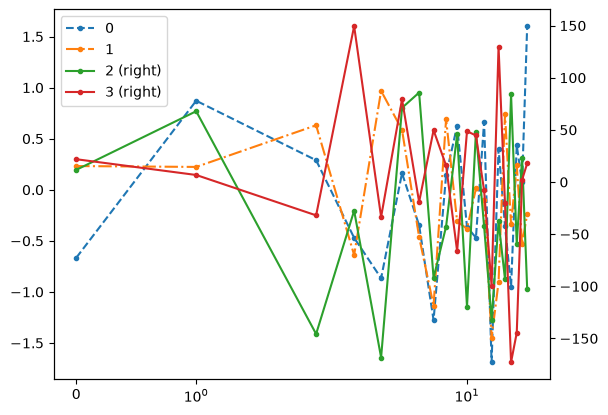

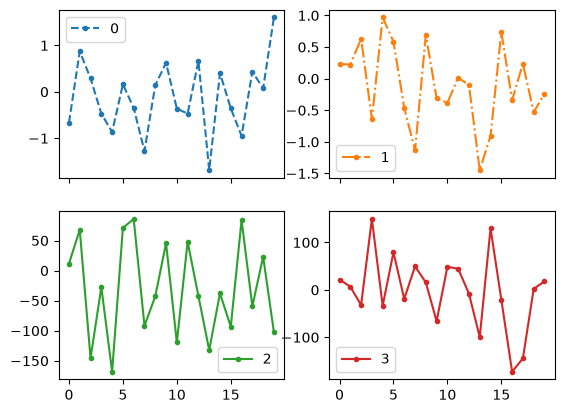

In [118]:
df = pd.DataFrame(rng.standard_normal((20, 4)))
df.iloc[:, 2:] *= 100  # 将数据中的后2组放大，将用右侧坐标轴刻度显示
p1 = df.plot(kind='line', marker='.',
             secondary_y=[2, 3],  # 右 y 轴
             style=['--', '-.', '-', '-'],  # 指定各条折线的线型
             logx='sym')  # symlog x 轴

p2 = df.plot(kind='line', marker='.',
             subplots=True,  # 将各数据系列分别绘制成子图
             layout=(2, 2),  # 指定子图的布局
             style=['--', '-.', '-', '-'])  # 指定各条折线的线型


### 散点图


<Axes: xlabel='x', ylabel='y'>

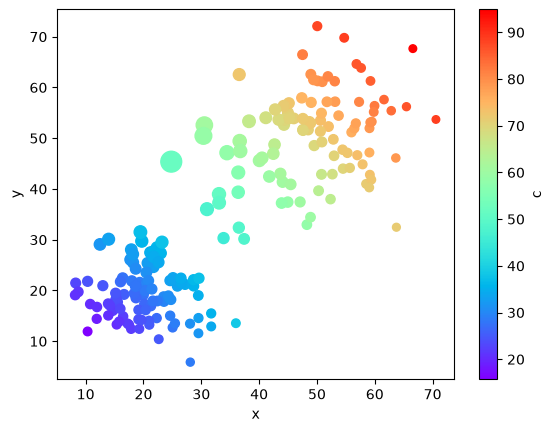

In [119]:
d1 = rng.normal(20, 5.5, (100, 2))
d2 = rng.normal(50, 8.5, (100, 2))
df = pd.DataFrame(np.vstack((d1, d2)), columns=['x', 'y'])
df['s'] = 1500/np.sqrt((df.x-20)**2+(df.y-50)**2)
df['c'] = np.sqrt((df.x)**2+(df.y)**2)

# 绘制散点图
df.plot(kind='scatter', x='x', y='y', s='s', c='c', colormap='rainbow')


### 条形图


<Axes: >

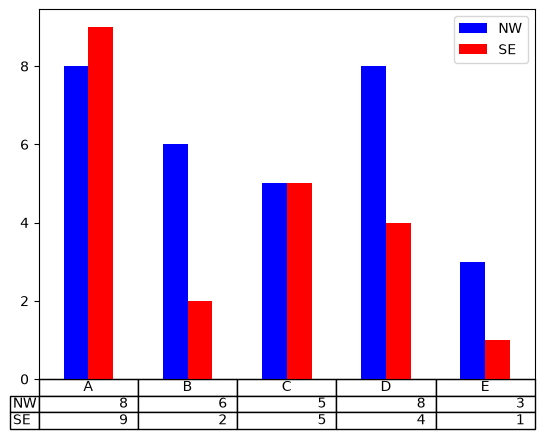

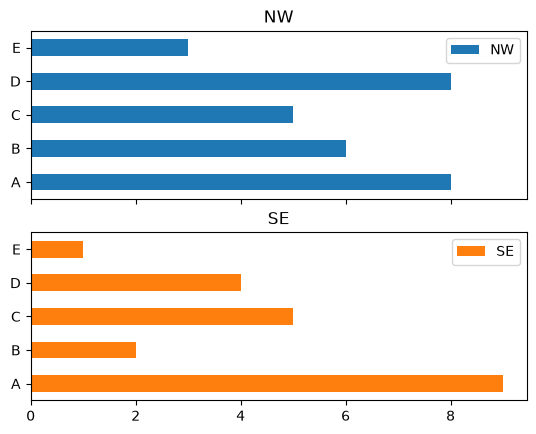

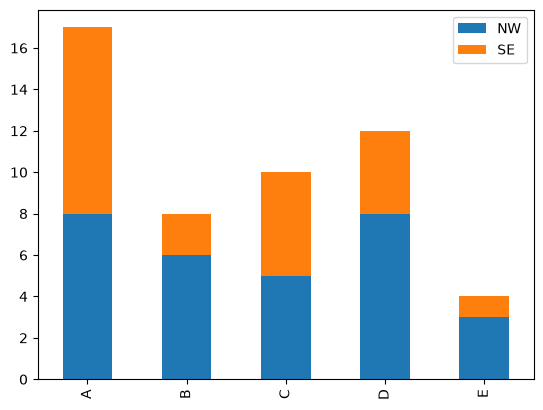

In [120]:
df = pd.DataFrame(rng.integers(1, 10, (5, 2)),
                  columns=['NW', 'SE'], index=list('ABCDE'))

df.plot(kind='bar',  # 垂直条形图
        color=dict(NW='b', SE='r'),  # 指定条形块的颜色
        table=True,  # 设置显示数据表
        xticks=[])
df.plot(kind='barh', subplots=True)  # 水平条形图
df.plot(kind='bar', stacked=True)  # 堆积垂直条形图


### 统计直方图


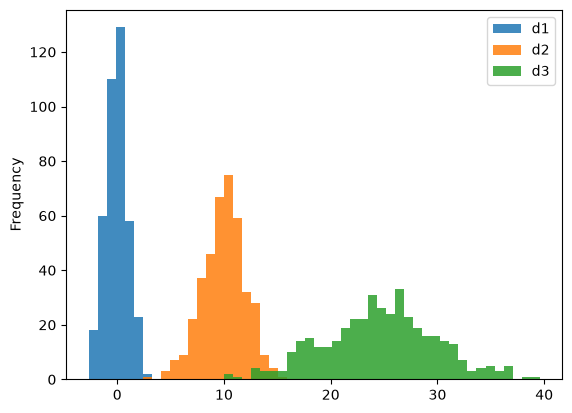

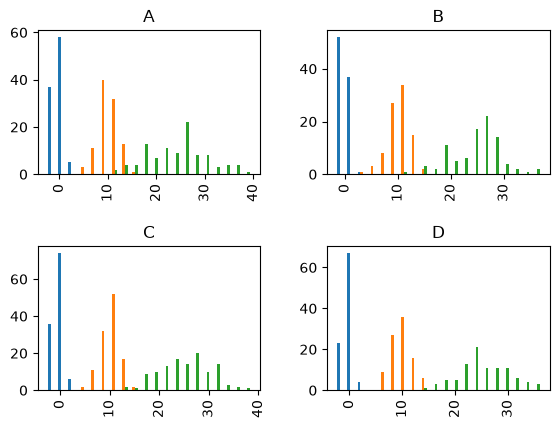

In [121]:
# 三组分布数据
d1 = rng.standard_normal(400)
d2 = rng.normal(10, 2, (400, ))
d3 = rng.normal(25, 5, (400, ))
df = pd.DataFrame({'d1': d1, 'd2': d2, 'd3': d3})
df['type'] = rng.choice(list('ABCD'), size=400)  # type 列

ax1 = df.plot(kind='hist', bins=50, alpha=0.85)  # 显示为50条
ax2 = df.hist(by='type', bins=20, layout=(2, 2))  # 按 type 分组


### 饼图


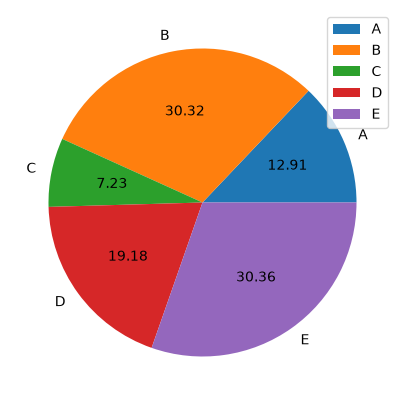

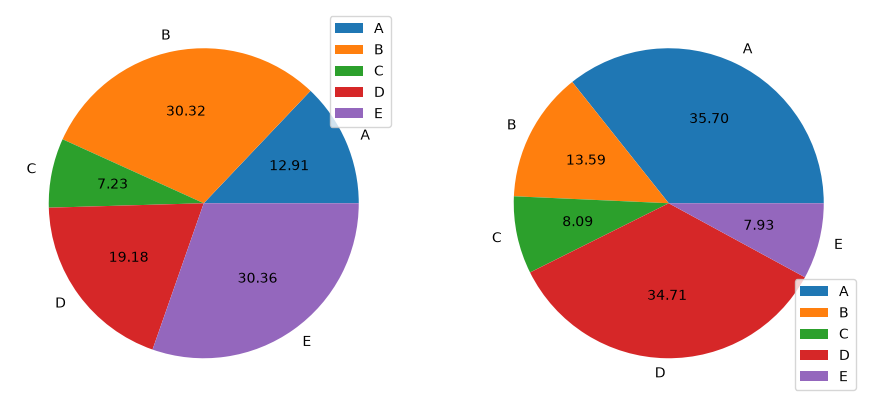

In [122]:
# 产生数据
df = pd.DataFrame(rng.random((5, 2)),
                  columns=['NW', 'SE'],
                  index=list('ABCDE'))

p1 = df.plot.pie(y='NW',  # NW 饼图
                 figsize=(5, 5),
                 autopct='%.2f')  # 显示的数值保留2位小数

p2 = df.plot(kind='pie',
             subplots=True,  # 在不同的子图中分别绘制数据系列
             figsize=(11, 6),
             autopct='%.2f')  # 显示的数值保留2位小数


### 密度分布图


<Axes: title={'center': 'BW:scott'}, ylabel='Density'>

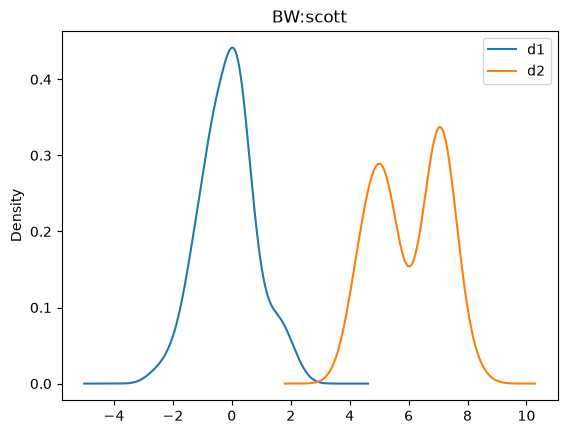

In [123]:
d1 = rng.standard_normal(100)
d2 = np.hstack((rng.normal(5, 0.5, (50, )),
                rng.normal(7, 0.5, (50, ))))
df = pd.DataFrame({'d1': d1, 'd2': d2})

df.plot(kind='density', title='BW:scott')  # 默认带宽


### 散点及分布矩阵图


array([[<Axes: xlabel='sepal length (cm)', ylabel='sepal length (cm)'>,
        <Axes: xlabel='sepal width (cm)', ylabel='sepal length (cm)'>,
        <Axes: xlabel='petal length (cm)', ylabel='sepal length (cm)'>,
        <Axes: xlabel='petal width (cm)', ylabel='sepal length (cm)'>],
       [<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>,
        <Axes: xlabel='sepal width (cm)', ylabel='sepal width (cm)'>,
        <Axes: xlabel='petal length (cm)', ylabel='sepal width (cm)'>,
        <Axes: xlabel='petal width (cm)', ylabel='sepal width (cm)'>],
       [<Axes: xlabel='sepal length (cm)', ylabel='petal length (cm)'>,
        <Axes: xlabel='sepal width (cm)', ylabel='petal length (cm)'>,
        <Axes: xlabel='petal length (cm)', ylabel='petal length (cm)'>,
        <Axes: xlabel='petal width (cm)', ylabel='petal length (cm)'>],
       [<Axes: xlabel='sepal length (cm)', ylabel='petal width (cm)'>,
        <Axes: xlabel='sepal width (cm)', ylabel='petal width (cm)'>,
  

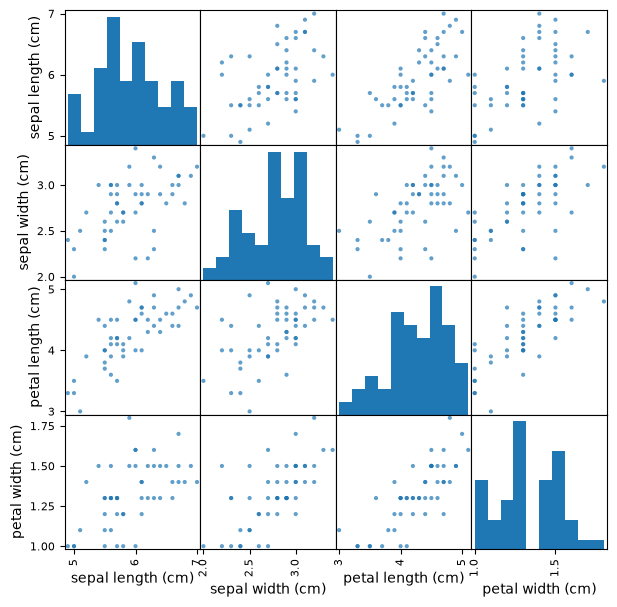

In [124]:
# 鸢尾花数据
from sklearn.datasets import load_iris
iris = load_iris(return_X_y=False)
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['target'] = iris.target
# versicolor 子集
pd.plotting.scatter_matrix(
    df_iris[df_iris.target == 1].drop('target', axis=1),
    alpha=0.7, figsize=(7, 7), diagonal='hist'
)
